# EDA desde cero — denuncias de violencia contra la mujer (2020–2025)

Este cuaderno parte exclusivamente del archivo crudo `BD_2020-2025.csv`. Su objetivo es describir, auditar y documentar la base **antes** de eliminar columnas, imputar valores, recodificar categorías o definir variables para modelado.

> Alcance ético: los resultados son descriptivos de registros administrativos; no representan prevalencia poblacional ni permiten inferir causalidad. No se deben publicar tablas o gráficos que puedan reidentificar personas o casos con conteos pequeños.

## Cómo usarlo en VS Code

1. Abra esta carpeta en VS Code y seleccione un kernel Python con `pandas`, `numpy`, `matplotlib` y `seaborn`.
2. Ejecute las celdas en orden. La primera pasada lee el CSV por bloques de 100 000 filas, por lo que funciona sin cargar sus ~937 mil registros completos en RAM.
3. Revise las salidas y complete las celdas de decisión antes de cualquier limpieza o modelado. Los reportes se guardan en `salidas_eda/`.

El tamaño de la muestra reproducible puede ajustarse con `SAMPLE_SIZE`; no cambia los conteos de nulos, frecuencias ni la serie temporal, que se calculan sobre toda la base.

In [1]:
from pathlib import Path
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'BD_2020-2025.csv'
OUTPUT_DIR = BASE_DIR / 'salidas_eda'
OUTPUT_DIR.mkdir(exist_ok=True)

CHUNK_SIZE = 100_000
SAMPLE_SIZE = 50_000
RANDOM_SEED = 20260827
MISSING_TOKENS = ['', ' ', 'NA', 'N/A', 'NULL', 'null']

assert DATA_PATH.exists(), f'No se encontró el archivo: {DATA_PATH}'
print(f'Archivo: {DATA_PATH.name}')
print(f'Tamaño: {DATA_PATH.stat().st_size / 1024**2:.1f} MB')

Archivo: BD_2020-2025.csv
Tamaño: 350.5 MB


## 1. Contrato inicial y nombres de columnas

No se modifican los nombres originales en la fuente. Se crea una versión normalizada solo para análisis y se conserva el mapeo para trazabilidad.

In [2]:
raw_columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()

def normalizar_nombre(nombre: str) -> str:
    nombre = unicodedata.normalize('NFKD', nombre).encode('ascii', 'ignore').decode('ascii')
    return (nombre.strip().lower().replace('ñ', 'n')
            .replace(' ', '_').replace('-', '_').replace('/', '_'))

column_map = pd.DataFrame({
    'columna_original': raw_columns,
    'columna_normalizada': [normalizar_nombre(c) for c in raw_columns],
})
assert column_map['columna_normalizada'].is_unique, 'La normalización produjo nombres duplicados.'
column_map.to_csv(OUTPUT_DIR / 'diccionario_columnas_inicial.csv', index=False, encoding='utf-8-sig')
display(column_map.head())
print(f'Columnas: {len(raw_columns)}')

,columna_original,columna_normalizada
0,CEM,cem
1,CONDICION,condicion
2,FECHA_INGRESO,fecha_ingreso
3,INFORMANTE,informante
4,FORMA_INGRESO,forma_ingreso


Columnas: 186


## 2. Perfilado completo por bloques

Esta primera pasada calcula tamaño, ausencia, frecuencias y serie temporal con todos los registros. Las categorías se mantienen como texto deliberadamente: evita que códigos como `01` pierdan ceros o se interpreten como medidas numéricas.

In [3]:
total_rows = 0
missing_counts = pd.Series(0, index=raw_columns, dtype='int64')
non_missing_counts = pd.Series(0, index=raw_columns, dtype='int64')
value_counts = {col: pd.Series(dtype='int64') for col in raw_columns}
monthly_counts = pd.Series(dtype='int64')
sample_parts = []
sample_fraction = min(1.0, SAMPLE_SIZE / 900_000)

for chunk_number, chunk in enumerate(pd.read_csv(
    DATA_PATH, dtype='string', keep_default_na=True, na_values=MISSING_TOKENS,
    chunksize=CHUNK_SIZE, low_memory=False
)):
    total_rows += len(chunk)
    missing_counts = missing_counts.add(chunk.isna().sum().astype('int64'), fill_value=0).astype('int64')
    non_missing_counts = non_missing_counts.add(chunk.notna().sum().astype('int64'), fill_value=0).astype('int64')

    for col in raw_columns:
        counts = chunk[col].dropna().value_counts()
        value_counts[col] = value_counts[col].add(counts, fill_value=0).astype('int64')

    dates = pd.to_datetime(chunk['FECHA_INGRESO'], errors='coerce', dayfirst=False)
    counts_by_month = dates.dt.to_period('M').value_counts()
    monthly_counts = monthly_counts.add(counts_by_month, fill_value=0).astype('int64')

    sample_parts.append(chunk.sample(frac=sample_fraction, random_state=RANDOM_SEED + chunk_number))

df_sample = pd.concat(sample_parts, ignore_index=True).sample(
    n=min(SAMPLE_SIZE, sum(len(x) for x in sample_parts)), random_state=RANDOM_SEED
).reset_index(drop=True)

profile = pd.DataFrame({
    'columna_original': raw_columns,
    'columna_normalizada': column_map['columna_normalizada'],
    'no_nulos': non_missing_counts.values,
    'nulos': missing_counts.values,
    'pct_nulos': (missing_counts / total_rows * 100).round(2).values,
    'categorias_observadas': [len(value_counts[c]) for c in raw_columns],
    'ejemplo_moda': [value_counts[c].index[0] if len(value_counts[c]) else pd.NA for c in raw_columns],
    'frecuencia_moda': [int(value_counts[c].iloc[0]) if len(value_counts[c]) else 0 for c in raw_columns],
})
profile['pct_moda_no_nulos'] = np.where(
    profile['no_nulos'].gt(0), (profile['frecuencia_moda'] / profile['no_nulos'] * 100).round(2), np.nan
)
profile.to_csv(OUTPUT_DIR / 'perfil_variables_completo.csv', index=False, encoding='utf-8-sig')

print(f'Registros: {total_rows:,}')
print(f'Variables: {len(raw_columns)}')
print(f'Muestra reproducible: {len(df_sample):,}')
display(profile.sort_values('pct_nulos', ascending=False).head(20))

Registros: 936,835
Variables: 186
Muestra reproducible: 50,000


,columna_original,columna_normalizada,no_nulos,nulos,pct_nulos,categorias_observadas,ejemplo_moda,frecuencia_moda,pct_moda_no_nulos
12,VICTIMA_SOLICITANTE_ASILO,victima_solicitante_asilo,32,936803,100.00,1,1,32,100.00
13,VICTIMA_ASILADO,victima_asilado,15,936820,100.00,1,1,15,100.00
14,VICTIMA_APATRIDA,victima_apatrida,5,936830,100.00,1,1,5,100.00
48,AGRESOR_ASILADO,agresor_asilado,11,936824,100.00,1,1,11,100.00
47,AGRESOR_SOLICITANTE_ASILO,agresor_solicitante_asilo,20,936815,100.00,1,1,20,100.00
49,AGRESOR_APATRIDA,agresor_apatrida,7,936828,100.00,1,1,7,100.00
146,VIOLENCIA_CARCELARIA,violencia_carcelaria,1,936834,100.00,1,1,1,100.00
174,ACOSO_POLITICO,acoso_politico,39,936796,100.00,1,1,39,100.00
175,VIOLENCIA_TICS,violencia_tics,119,936716,99.99,1,1,119,100.00
69,PERCEPCION_SALARIO_MENOR,percepcion_salario_menor,87,936748,99.99,1,1,87,100.00


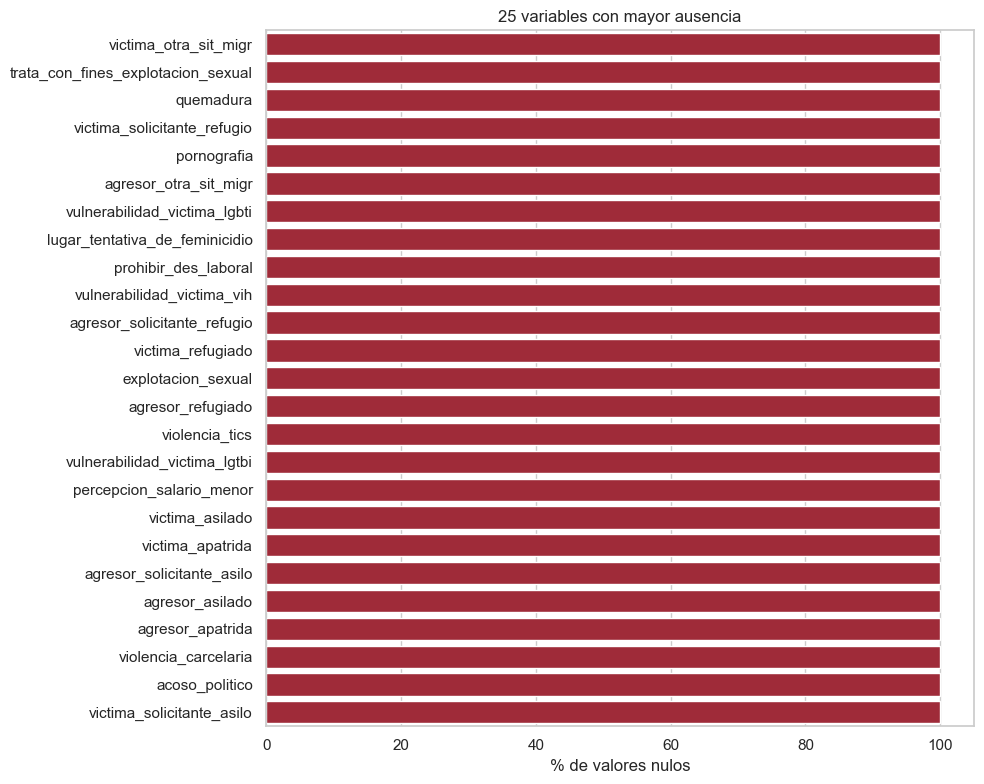

,columna_original,pct_nulos,categorias_observadas
12,VICTIMA_SOLICITANTE_ASILO,100.00,1
47,AGRESOR_SOLICITANTE_ASILO,100.00,1
48,AGRESOR_ASILADO,100.00,1
14,VICTIMA_APATRIDA,100.00,1
13,VICTIMA_ASILADO,100.00,1
...,...,...,...
120,TRATAMIENTO_PSICOLOGICO,96.44,1
133,VINCULO_AFECTIVO_NINGUNO,96.20,1
84,VIGILANCIA_CONTINUA_PERSECUCION,96.03,1
100,NEGLIGENCIA,95.88,1


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
top_missing = profile.nlargest(25, 'pct_nulos').sort_values('pct_nulos')
sns.barplot(data=top_missing, x='pct_nulos', y='columna_normalizada', color='#b2182b', ax=ax)
ax.set(title='25 variables con mayor ausencia', xlabel='% de valores nulos', ylabel='')
plt.tight_layout()
plt.show()

# Regla diagnóstica, no regla de eliminación: se debe evaluar significado y periodo de captura.
display(profile.query('pct_nulos >= 95')[['columna_original', 'pct_nulos', 'categorias_observadas']].sort_values('pct_nulos', ascending=False))

## 3. Integridad temporal y cambios de formulario

Un valor ausente puede significar “no aplica”, “no fue preguntado” o una variable incorporada después. Por eso se revisa la cobertura por año antes de tratar la ausencia como dato faltante.

C:\Users\jcollazos\AppData\Local\Temp\ipykernel_33860\3891858833.py:3: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_dia_mes = pd.to_datetime(df_sample['FECHA_INGRESO'], errors='coerce', dayfirst=True)


No interpretables mes/día/año: 0.00%
No interpretables día/mes/año: 0.00%
Fechas con mes distinto según convención: 0.00%
Fechas no interpretables bajo hipótesis provisional: 0 (0.00%)
Rango temporal en muestra: 2020-01-01 00:00:00 a 2025-12-31 00:00:00


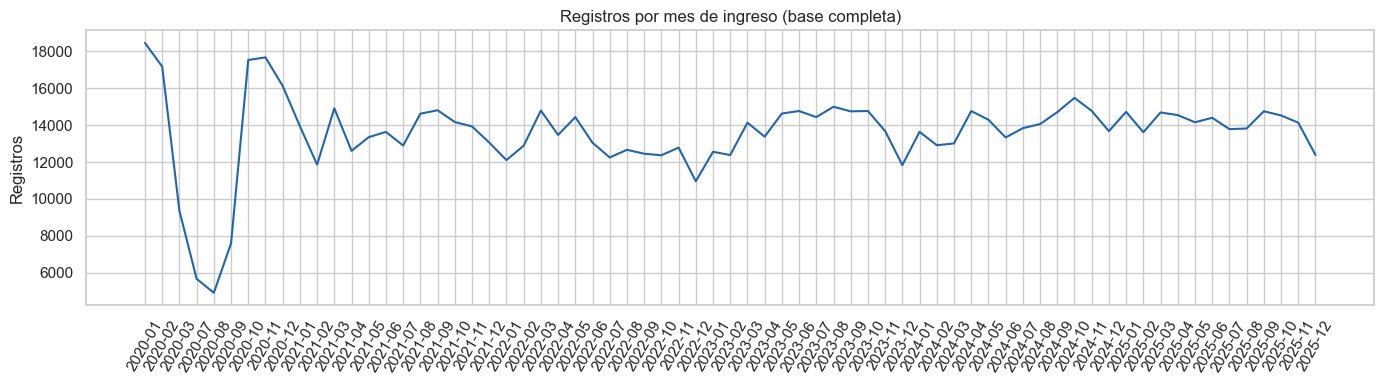

In [5]:
# La lectura inicial usa mes/día/año; contraste ambas convenciones antes de fijarla en una limpieza posterior.
fecha_mes_dia = pd.to_datetime(df_sample['FECHA_INGRESO'], errors='coerce', dayfirst=False)
fecha_dia_mes = pd.to_datetime(df_sample['FECHA_INGRESO'], errors='coerce', dayfirst=True)
print(f'No interpretables mes/día/año: {fecha_mes_dia.isna().mean():.2%}')
print(f'No interpretables día/mes/año: {fecha_dia_mes.isna().mean():.2%}')
print(f'Fechas con mes distinto según convención: {(fecha_mes_dia.dt.month != fecha_dia_mes.dt.month).fillna(False).mean():.2%}')
df_sample['fecha_ingreso_dt'] = fecha_mes_dia  # Hipótesis provisional para visualizar; validar con la fuente.
invalid_dates = int(df_sample['fecha_ingreso_dt'].isna().sum())
print(f'Fechas no interpretables bajo hipótesis provisional: {invalid_dates:,} ({invalid_dates / len(df_sample):.2%})')
print('Rango temporal en muestra:', df_sample['fecha_ingreso_dt'].min(), 'a', df_sample['fecha_ingreso_dt'].max())

monthly = monthly_counts.rename_axis('periodo').reset_index(name='denuncias')
monthly['periodo'] = monthly['periodo'].astype(str)
monthly = monthly.sort_values('periodo')
monthly.to_csv(OUTPUT_DIR / 'serie_temporal_mensual_cruda.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['periodo'], monthly['denuncias'], color='#2166ac', linewidth=1.5)
ax.set(title='Registros por mes de ingreso (base completa)', xlabel='', ylabel='Registros')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

In [6]:
coverage_by_year = (
    df_sample.assign(anio=df_sample['fecha_ingreso_dt'].dt.year)
    .groupby('anio', dropna=False)[raw_columns]
    .agg(lambda s: s.notna().mean() * 100)
    .T.reset_index(names='columna_original')
)
coverage_by_year.to_csv(OUTPUT_DIR / 'cobertura_variables_muestra_por_anio.csv', index=False, encoding='utf-8-sig')

variables_revision = ['TIPO_VIOLENCIA', 'NIVEL_DE_RIESGO_VICTIMA', 'ACOSO_POLITICO', 'VIOLENCIA_TICS', 'MODALIDADES_VCM']
variables_revision = [v for v in variables_revision if v in coverage_by_year['columna_original'].values]
display(coverage_by_year[coverage_by_year['columna_original'].isin(variables_revision)])

anio,columna_original,2020,2021,2022,2023,2024,2025
147,NIVEL_DE_RIESGO_VICTIMA,100.0,100.000000,100.000000,100.000000,100.000000,100.000000
157,TIPO_VIOLENCIA,100.0,100.000000,100.000000,100.000000,100.000000,100.000000
174,ACOSO_POLITICO,0.0,0.000000,0.000000,0.022566,0.000000,0.000000
175,VIOLENCIA_TICS,0.0,0.011409,0.024372,0.022566,0.000000,0.000000
184,MODALIDADES_VCM,0.0,0.000000,0.000000,18.142841,83.791913,83.828237


## 4. Distribuciones, consistencia y privacidad

Las funciones siguientes muestran categorías tal como fueron registradas. Antes de recodificar, se deben identificar códigos, categorías ambiguas y combinaciones imposibles con la documentación de la fuente. Para difusión, suprima o agrupe resultados con menos de 5 registros.

In [7]:
def tabla_frecuencias(columna, top_n=15, min_publicable=5):
    tabla = value_counts[columna].rename_axis(columna).reset_index(name='n')
    tabla['pct'] = (tabla['n'] / total_rows * 100).round(2)
    tabla['difusion_segura'] = np.where(tabla['n'] >= min_publicable, tabla[columna].astype('string'), '<5 / suprimido>')
    return tabla.head(top_n)

variables_clave = [
    'CEM', 'SEXO_VICTIMA', 'EDAD_VICTIMA', 'TIPO_VIOLENCIA',
    'NIVEL_DE_RIESGO_VICTIMA', 'VINCULO_AGRESOR_VICTIMA',
    'DPTO_DOMICILIO', 'AREA_RESIDENCIA_DOMICILIO', 'INTERPUSO_DENUNCIA'
]
for variable in [v for v in variables_clave if v in raw_columns]:
    print(f'\n{variable}')
    display(tabla_frecuencias(variable, top_n=12))


CEM


,CEM,n,pct,difusion_segura
0,ABANCAY,1118,0.12,ABANCAY
1,ACOBAMBA,1251,0.13,ACOBAMBA
2,ACOMAYO,1023,0.11,ACOMAYO
3,ACORA,875,0.09,ACORA
4,AGUAS VERDES,611,0.07,AGUAS VERDES
5,AIJA,515,0.05,AIJA
6,ALTO SELVA ALEGRE,1415,0.15,ALTO SELVA ALEGRE
7,AMBO,1686,0.18,AMBO
8,ANCON,315,0.03,ANCON
9,ANDAHUAYLAS,2023,0.22,ANDAHUAYLAS



SEXO_VICTIMA


,SEXO_VICTIMA,n,pct,difusion_segura
0,0,798329,85.22,0
1,1,138506,14.78,1



EDAD_VICTIMA


...

,DPTO_DOMICILIO,n,pct,difusion_segura
0,1,11455,1.22,1
1,10,28752,3.07,10
2,11,34421,3.67,11
3,12,41119,4.39,12
4,13,45760,4.88,13
5,14,23077,2.46,14
6,15,253936,27.11,15
7,16,17348,1.85,16
8,17,6968,0.74,17
9,18,9000,0.96,18



AREA_RESIDENCIA_DOMICILIO


,AREA_RESIDENCIA_DOMICILIO,n,pct,difusion_segura
0,1,617235,65.89,1
1,2,124796,13.32,2
2,R,33778,3.61,R
3,U,161026,17.19,U



INTERPUSO_DENUNCIA


,INTERPUSO_DENUNCIA,n,pct,difusion_segura
0,0,204174,21.79,0
1,1,732661,78.21,1


In [8]:
# Revisión de rangos en la muestra. No se corrige nada aquí: se marcan casos para contrastar con el diccionario de datos.
for variable in ['EDAD_VICTIMA', 'EDAD_AGRESOR', 'HIJAS_VIVAS', 'HIJOS_VIVOS']:
    if variable in df_sample.columns:
        numerica = pd.to_numeric(df_sample[variable], errors='coerce')
        print(f'{variable}: mínimo={numerica.min()}, máximo={numerica.max()}, nulos={numerica.isna().mean():.2%}')

if {'SEXO_VICTIMA', 'EDAD_VICTIMA'}.issubset(df_sample.columns):
    edad_victima = pd.to_numeric(df_sample['EDAD_VICTIMA'], errors='coerce')
    display(pd.crosstab(df_sample['SEXO_VICTIMA'], edad_victima.isna(), normalize='index').round(3))

sample_duplicates = int(df_sample.duplicated().sum())
print(f'Filas completamente duplicadas en la muestra: {sample_duplicates:,}')
print('Nota: una deduplicación real requiere un identificador de caso o reglas validadas; no se infiere desde estas variables.')

EDAD_VICTIMA: mínimo=0, máximo=104, nulos=0.00%
EDAD_AGRESOR: mínimo=8, máximo=92, nulos=1.91%
HIJAS_VIVAS: mínimo=0.0, máximo=8.0, nulos=79.16%
HIJOS_VIVOS: mínimo=0.0, máximo=8.0, nulos=79.16%


EDAD_VICTIMA,False
SEXO_VICTIMA,
0,1.0
1,1.0


Filas completamente duplicadas en la muestra: 5
Nota: una deduplicación real requiere un identificador de caso o reglas validadas; no se infiere desde estas variables.


## 5. Registro de decisiones — contraste con el repositorio anterior

El repositorio anterior documenta: normalización de columnas, enriquecimiento UBIGEO, eliminación por alta ausencia, imputación por tipo semántico, exclusión de violencia económica para modelado y filtro de baja varianza. Este EDA difiere deliberadamente: primero mide calidad y cobertura temporal; no elimina ni imputa variables en la fase descriptiva.

Las decisiones que apruebe aquí deben registrar evidencia, responsable y fecha. La tabla se exporta como bitácora comparable, no como una instrucción automática de limpieza.

In [9]:
decision_log = pd.DataFrame([
    ['Normalizar nombres', 'Sí, solo en capa analítica; conservar originales.', 'Mapa de columnas exportado.', 'Pendiente'],
    ['Eliminar por alta ausencia', 'No antes de revisar cobertura por año y significado.', 'perfil_variables_completo.csv + cobertura por año.', 'Pendiente'],
    ['Imputar valores', 'No en EDA; distinguir no aplica, no capturado y faltante real.', 'Frecuencias, diccionario y regla por variable.', 'Pendiente'],
    ['Enriquecer UBIGEO', 'Posponer hasta validar códigos, ceros a la izquierda y fuente maestra.', 'Tasa de match y casos no emparejados.', 'Pendiente'],
    ['Excluir violencia económica', 'No en EDA; evaluar distribución y justificar solo para un target concreto.', 'Conteos, objetivo de modelado y sesgo inducido.', 'Pendiente'],
    ['Filtro de baja varianza', 'No en EDA; aplicar solo dentro del pipeline de entrenamiento.', 'Definición de target, split temporal y prevención de fuga.', 'Pendiente'],
], columns=['decision_previa', 'criterio_desde_cero', 'evidencia_requerida', 'estado'])
decision_log.to_csv(OUTPUT_DIR / 'registro_decisiones_eda.csv', index=False, encoding='utf-8-sig')
display(decision_log)

,decision_previa,criterio_desde_cero,evidencia_requerida,estado
0,Normalizar nombres,"Sí, solo en capa analítica; conservar originales.",Mapa de columnas exportado.,Pendiente
1,Eliminar por alta ausencia,No antes de revisar cobertura por año y signif...,perfil_variables_completo.csv + cobertura por ...,Pendiente
2,Imputar valores,"No en EDA; distinguir no aplica, no capturado ...","Frecuencias, diccionario y regla por variable.",Pendiente
3,Enriquecer UBIGEO,"Posponer hasta validar códigos, ceros a la izq...",Tasa de match y casos no emparejados.,Pendiente
4,Excluir violencia económica,No en EDA; evaluar distribución y justificar s...,"Conteos, objetivo de modelado y sesgo inducido.",Pendiente
5,Filtro de baja varianza,No en EDA; aplicar solo dentro del pipeline de...,"Definición de target, split temporal y prevenc...",Pendiente


## 6. Cierre del EDA: decisiones para la siguiente fase

Antes de crear una base limpia o un modelo, responda y deje la evidencia en la bitácora:

- ¿Qué representa una fila: atención, denuncia, persona o evento? ¿Hay un identificador confiable para deduplicar?
- ¿Qué columnas cambian de cobertura según el año y, por tanto, no son comparables históricamente?
- ¿Cuáles son los targets y cuándo están disponibles respecto al momento de predicción? Esto previene fuga de información.
- ¿Qué variables requieren diccionario, recodificación o validación con la fuente antes de interpretarse?
- ¿Qué nivel geográfico y qué umbral de supresión protege mejor la confidencialidad?

Solo tras responderlas conviene abrir un segundo notebook de limpieza/versionado, con decisiones aprobadas y reglas testeables.